# Q1: Sales Trend Analysis

## Business Question
How has total sales evolved over time, and are there observable seasonal patterns?

## Objective
To analyze monthly revenue trends and identify recurring seasonality across years.


## Data Preparation

We use the cleaned dataset generated in the processing step. The dataset excludes cancelled transactions and invalid records (Quantity ≤ 0 and Price ≤ 0).


In [84]:
import pandas as pd
df = pd.read_csv('../data/processed/retail_cleaned.csv')

C:\Users\kitki\AppData\Local\Temp\ipykernel_43516\2254436791.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/retail_cleaned.csv')


In [85]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [86]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041670 entries, 0 to 1041669
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1041670 non-null  object 
 1   StockCode    1041670 non-null  object 
 2   Description  1041670 non-null  object 
 3   Quantity     1041670 non-null  int64  
 4   InvoiceDate  1041670 non-null  object 
 5   Price        1041670 non-null  float64
 6   Customer_ID  805549 non-null   float64
 7   Country      1041670 non-null  object 
 8   TotalSales   1041670 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 71.5+ MB


In [87]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [88]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalSales,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


## Monthly Revenue Aggregation

To analyze trends, revenue is aggregated at the Year-Month level.


In [89]:
## Analyze sales trend over time
monthly_sales = df.groupby('YearMonth')['TotalSales'].sum().sort_index()
monthly_sales.head()


YearMonth
2009-12    825685.760
2010-01    652708.502
2010-02    553339.736
2010-03    833570.131
2010-04    681528.992
Name: TotalSales, dtype: float64

In [90]:
monthly_sales.tail()

YearMonth
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638810.680
Name: TotalSales, dtype: float64

## Monthly Sales Trend Visualization

A line chart is used to observe revenue trends over time.


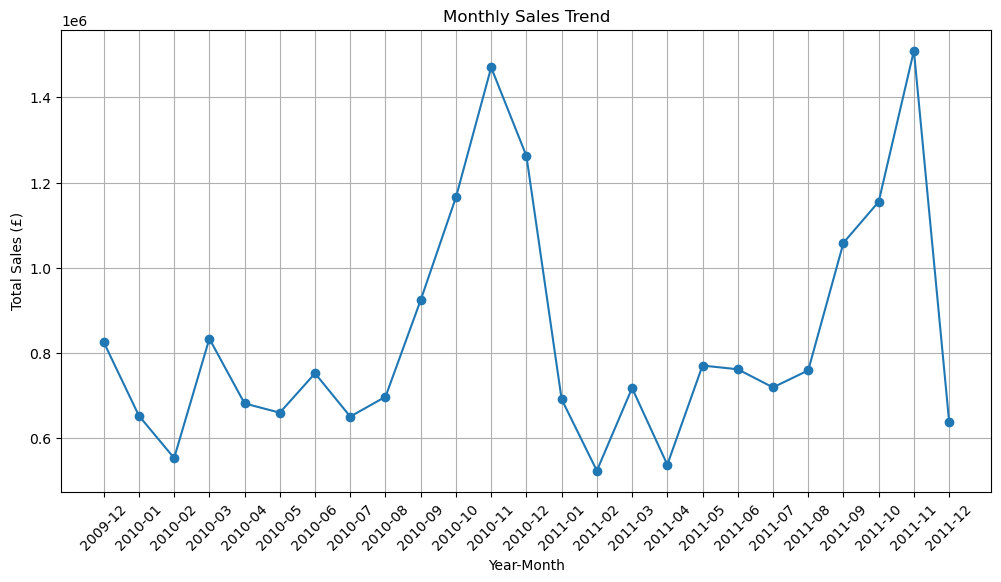

In [91]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [92]:
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df['YearMonth'] = pd.to_datetime(monthly_sales_df['YearMonth'])
monthly_sales_df['Month'] = monthly_sales_df['YearMonth'].dt.month
monthly_sales_df.head()

,YearMonth,TotalSales,Month
0,2009-12-01,825685.760,12
1,2010-01-01,652708.502,1
2,2010-02-01,553339.736,2
3,2010-03-01,833570.131,3
4,2010-04-01,681528.992,4


In [93]:
## Analyze seasonal patterns by month
seasonal_pattern_avg_revenue = monthly_sales_df.groupby('Month')['TotalSales'].mean()
seasonal_pattern_avg_revenue.sort_values(ascending=False)

Month
11    1.489884e+06
10    1.160232e+06
9     9.914616e+05
12    9.090317e+05
3     7.756047e+05
6     7.570050e+05
8     7.282066e+05
5     7.151974e+05
7     6.849671e+05
1     6.720365e+05
4     6.096688e+05
2     5.384858e+05
Name: TotalSales, dtype: float64

In [94]:
monthly_orders = df.groupby('YearMonth')['Invoice'].nunique()
monthly_orders.head(20)

YearMonth
2009-12    1682
2010-01    1105
2010-02    1201
2010-03    1681
2010-04    1462
2010-05    1500
2010-06    1645
2010-07    1529
2010-08    1425
2010-09    1839
2010-10    2301
2010-11    2747
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1476
Name: Invoice, dtype: int64

In [95]:
monthly_aov = monthly_sales/ monthly_orders
monthly_aov.head(20)

YearMonth
2009-12    490.895220
2010-01    590.686427
2010-02    460.732503
2010-03    495.877532
2010-04    466.162101
2010-05    439.905907
2010-06    457.307076
2010-07    425.580733
2010-08    489.315726
2010-09    502.628065
2010-10    506.511912
2010-11    535.228424
2010-12    809.877351
2011-01    636.615617
2011-02    476.028991
2011-03    493.562146
2011-04    431.628107
2011-05    458.379548
2011-06    496.894912
2011-07    487.277230
dtype: float64

## Key Insights

- Sales exhibit a strong seasonal pattern.
- Revenue increases steadily from August and peaks in November.
- January and February show consistent post-holiday declines.
- The pattern remains consistent across both years, suggesting structural seasonality.


## Business Implications

- Inventory planning should prioritize stock availability before November peak.
- Marketing campaigns may be intensified before and during the pre-Christmas period.
- Promotional strategies can mitigate the post-holiday sales slump in Q1.
